# Wild-Tool-Bench — 120B Strategy Analysis

Analysis of the `openai/gpt-oss-120b` tool-selection-strategy runs:

`in_context`, `embedding`, `embedding_context`, `reranker`, `reranker_context`, `hierarchical`

Data sources used:
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_metric.json` — official aggregated accuracy/optimality/progress metrics.
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_score.jsonl` — per-task correctness (`label`), optimality, predicted tool calls and final answers.
- `result_v3_120B/<strategy>/langgraph/Wild-Tool-Bench_metrics_summary.jsonl` — per-task token counts and latency.
- `result_v3_120B/<strategy>/tool_selection_logs.jsonl` — candidate tools handed to the LLM by the selection strategy (absent for `in_context`).
- `result_v3_120B/<strategy>/tool_call_logs.jsonl` — tool calls actually issued by the executing LLM.
- `data/Wild-Tool-Bench.jsonl` — benchmark definition incl. gold trajectories (`english_answer_list`), task types and turn subtypes.

Sections:
1. Setup & data loading
2. Official WTB metrics (task/session accuracy, task type, layer, turn subtype, optimality, progress)
3. Token count & latency comparison
4. Token count vs. accuracy
5. Inter-strategy comparison: unique wins
6. Gold-tool coverage of the tool selection stage
7. Single-task deep dive: gold trajectory vs. selected/executed tools & answer


In [21]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "wild-tool-bench":
    ROOT = ROOT / "wild-tool-bench"

STRATEGIES = ["in_context", "embedding", "embedding_context", "reranker", "reranker_context", "hierarchical"]
STRATEGY_LABELS = {
    "in_context": "In-Context",
    "embedding": "Embedding",
    "embedding_context": "Embedding+Context",
    "reranker": "Reranker",
    "reranker_context": "Reranker+Context",
    "hierarchical": "Hierarchical",
}
SCORE_DIRS = {s: f"120B_{s}" for s in STRATEGIES}
COLORS = dict(zip(STRATEGIES, plt.cm.tab10.colors))

DATA_FILE = ROOT / "data/Wild-Tool-Bench.jsonl"
SCORE_ROOT = ROOT / "score"
RESULT_ROOT = ROOT / "result_v3_120B"


def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Setup & data loading

Builds a gold-task index (task type, turn subtype, layer, gold tool trajectory) from the benchmark
definition, then loads the per-task score/metrics/selection/tool-call logs for every strategy.


In [22]:
benchmark = read_jsonl(DATA_FILE)


def build_gold_index(rows: list[dict]) -> dict[tuple[str, int], dict]:
    """One entry per (session id, task_idx) with gold task metadata and the gold tool trajectory."""
    idx = {}
    for rec in rows:
        eid = rec["id"]
        n = len(rec["english_tasks"])
        for i in range(n):
            gold_actions = rec["english_answer_list"][i] if i < len(rec["english_answer_list"]) else []
            gold_tools = [
                a.get("action", {}).get("name")
                for a in gold_actions
                if a.get("action", {}).get("name") and a["action"]["name"] != "prepare_to_answer"
            ]
            idx[(eid, i)] = {
                "task_type": rec["english_task_types"][i],
                "turn_type": "First Turn" if not rec["turn_types"][i] else "Subsequent Turn",
                "turn_subtype": rec["english_turn_subtypes"][i - 1] if i > 0 else None,
                "layer": i,
                "query": rec["english_tasks"][i],
                "gold_tools": gold_tools,
                "gold_tools_unique": sorted(set(gold_tools)),
                "gold_actions": gold_actions,
            }
    return idx


gold_index = build_gold_index(benchmark)
print(f"{len(gold_index)} gold tasks across {len(benchmark)} sessions")


1024 gold tasks across 256 sessions


In [23]:
def extract_step_info(inference_log: dict) -> tuple[list[str], str | None]:
    """Returns (predicted tool names in call order, final answer text) for one task's inference log."""
    step_keys = sorted(
        (k for k in inference_log if str(k).startswith("step_")),
        key=lambda x: int(x.split("_")[1]),
    )
    predicted_tools, final_answer = [], None
    for sk in step_keys:
        out = inference_log[sk].get("inference_output", {}) or {}
        for tc in out.get("tool_calls", []) or []:
            fn = tc.get("function", {}) or {}
            if fn.get("name"):
                predicted_tools.append(fn["name"])
        if out.get("content"):
            final_answer = out["content"]
    return predicted_tools, final_answer


def load_strategy_tasks(strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task correctness/optimality/predicted tools/final answer from Wild-Tool-Bench_score.jsonl."""
    score_rows = read_jsonl(SCORE_ROOT / SCORE_DIRS[strategy] / "langgraph/Wild-Tool-Bench_score.jsonl")
    tasks = {}
    for rec in score_rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            log = item.get("inference_log", {}) or {}
            predicted_tools, final_answer = extract_step_info(log) if log else ([], None)
            tasks[(eid, i)] = {
                "correct": item.get("label") == "correct",
                "optimal": bool(item.get("is_optimal", False)),
                "predicted_tools": predicted_tools,
                "final_answer": final_answer,
            }
    return tasks


def load_strategy_token_metrics(strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task token/latency figures from Wild-Tool-Bench_metrics_summary.jsonl."""
    rows = read_jsonl(RESULT_ROOT / strategy / "langgraph/Wild-Tool-Bench_metrics_summary.jsonl")
    out = {}
    for rec in rows:
        eid = rec["id"]
        for pt in rec["metrics"].get("per_task", []):
            out[(eid, pt["task_idx"])] = {
                "input_tokens": pt.get("input_tokens", 0) or 0,
                "output_tokens": pt.get("output_tokens", 0) or 0,
                "total_tokens": pt.get("total_tokens", 0) or 0,
                "llm_latency_s": pt.get("llm_latency_s", 0) or 0,
                "embedding_total_tokens": pt.get("embedding_total_tokens", 0) or 0,
                "reranker_total_tokens": pt.get("reranker_total_tokens", 0) or 0,
                "selector_total_tokens": pt.get("selector_total_tokens", 0) or 0,
            }
    return out


def load_strategy_selection(strategy: str) -> dict[tuple[str, int], set[str]]:
    """Union of tool names ever offered to the LLM by the selection stage, per task."""
    path = RESULT_ROOT / strategy / "tool_selection_logs.jsonl"
    out = defaultdict(set)
    if not path.exists():
        return out
    for row in read_jsonl(path):
        out[(row["test_entry_id"], row["task_idx"])].update(row.get("selected_tool_names", []))
    return out


def load_strategy_tool_calls(strategy: str) -> dict[tuple[str, int], list[dict]]:
    """Actual tool calls issued by the executing LLM, per task, in chronological order."""
    rows = read_jsonl(RESULT_ROOT / strategy / "tool_call_logs.jsonl")
    rows.sort(key=lambda r: r.get("timestamp", 0))
    out = defaultdict(list)
    for row in rows:
        key = (row["test_entry_id"], row["task_idx"])
        for tc in row.get("returned_tool_calls", []) or []:
            out[key].append({"name": tc.get("name"), "arguments": tc.get("arguments")})
    return out


strategy_data = {}
for s in STRATEGIES:
    strategy_data[s] = {
        "tasks": load_strategy_tasks(s),
        "tokens": load_strategy_token_metrics(s),
        "selection": load_strategy_selection(s),
        "tool_calls": load_strategy_tool_calls(s),
        "metric": json.load(open(SCORE_ROOT / SCORE_DIRS[s] / "langgraph/Wild-Tool-Bench_metric.json")),
    }
    n_tasks = len(strategy_data[s]["tasks"])
    n_correct = sum(t["correct"] for t in strategy_data[s]["tasks"].values())
    print(f"{s:20s} tasks={n_tasks:4d}  correct={n_correct:4d}  acc={n_correct / n_tasks:.4f}")


in_context           tasks=1024  correct= 371  acc=0.3623
embedding            tasks=1024  correct= 327  acc=0.3193
embedding_context    tasks=1024  correct= 367  acc=0.3584
reranker             tasks=1024  correct= 314  acc=0.3066
reranker_context     tasks=1024  correct= 360  acc=0.3516
hierarchical         tasks=1024  correct= 373  acc=0.3643


In [24]:
rows = []
for s in STRATEGIES:
    tasks = strategy_data[s]["tasks"]
    tokens = strategy_data[s]["tokens"]
    for key, gold in gold_index.items():
        task = tasks.get(key, {"correct": False, "optimal": False, "predicted_tools": [], "final_answer": None})
        tok = tokens.get(key, {})
        rows.append({
            "strategy": s,
            "task_id": key[0],
            "task_idx": key[1],
            "task_type": gold["task_type"],
            "turn_type": gold["turn_type"],
            "turn_subtype": gold["turn_subtype"],
            "layer": gold["layer"],
            "correct": task["correct"],
            "optimal": task["optimal"],
            "total_tokens": tok.get("total_tokens", 0),
            "input_tokens": tok.get("input_tokens", 0),
            "output_tokens": tok.get("output_tokens", 0),
            "llm_latency_s": tok.get("llm_latency_s", 0),
            "pipeline_tokens": tok.get("total_tokens", 0) + tok.get("embedding_total_tokens", 0)
                + tok.get("reranker_total_tokens", 0) + tok.get("selector_total_tokens", 0),
        })
task_df = pd.DataFrame(rows)
task_df.head()


,strategy,task_id,task_idx,task_type,turn_type,turn_subtype,layer,correct,optimal,total_tokens,input_tokens,output_tokens,llm_latency_s,pipeline_tokens
0,in_context,wild_tool_bench_0,0,Single-Tool,First Turn,NaN,0,True,True,116631,116330,301,14.888,116631
1,in_context,wild_tool_bench_0,1,Single-Tool,Subsequent Turn,Partial Information,1,True,True,117053,116874,179,7.025,117053
2,in_context,wild_tool_bench_0,2,Mixed Multi-Tool,Subsequent Turn,Partial Information,2,False,False,58818,58608,210,8.077,58818
3,in_context,wild_tool_bench_0,3,Chat,Subsequent Turn,Coreferential Reference,3,True,True,59496,59251,245,9.354,59496
4,in_context,wild_tool_bench_1,0,Single-Tool,First Turn,NaN,0,False,False,116400,116045,355,16.646,116400


## 2. Official WTB metrics

Directly visualizes the numbers already computed in each strategy's `Wild-Tool-Bench_metric.json`:
task/session accuracy, task-type accuracy, layer (turn position) accuracy, turn-subtype accuracy,
optimality score and progress info.


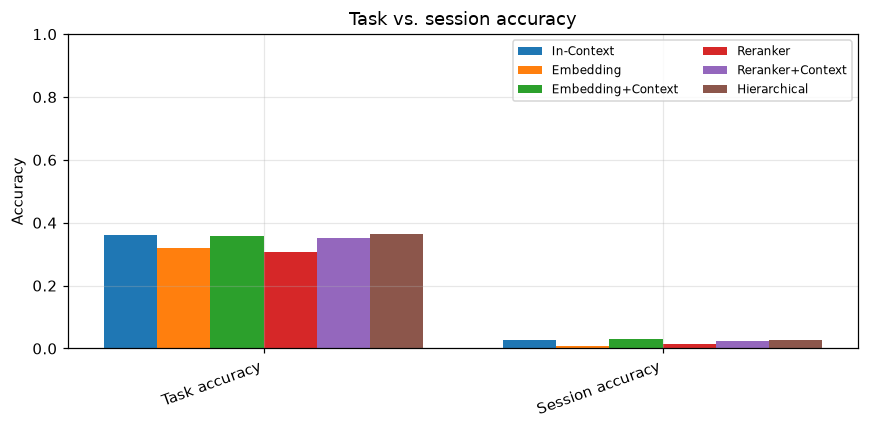

In [25]:
def grouped_bar(ax, categories: list[str], series: dict[str, list[float]], ylabel: str, title: str, pct: bool = True):
    n_groups, n_series = len(categories), len(series)
    width = 0.8 / n_series
    x = range(n_groups)
    for i, (s, values) in enumerate(series.items()):
        offsets = [xi + i * width - 0.4 + width / 2 for xi in x]
        ax.bar(offsets, values, width=width, label=STRATEGY_LABELS[s], color=COLORS[s])
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if pct:
        ax.set_ylim(0, max(1.0, max(v for vals in series.values() for v in vals) * 1.15))
    ax.legend(fontsize=8, ncol=2)


# Task & session accuracy
categories = ["Task accuracy", "Session accuracy"]
series = {
    s: [strategy_data[s]["metric"]["total_info"]["task"]["accuracy"],
        strategy_data[s]["metric"]["total_info"]["session"]["accuracy"]]
    for s in STRATEGIES
}
fig, ax = plt.subplots(figsize=(8, 4))
grouped_bar(ax, categories, series, "Accuracy", "Task vs. session accuracy")
plt.tight_layout()
plt.show()


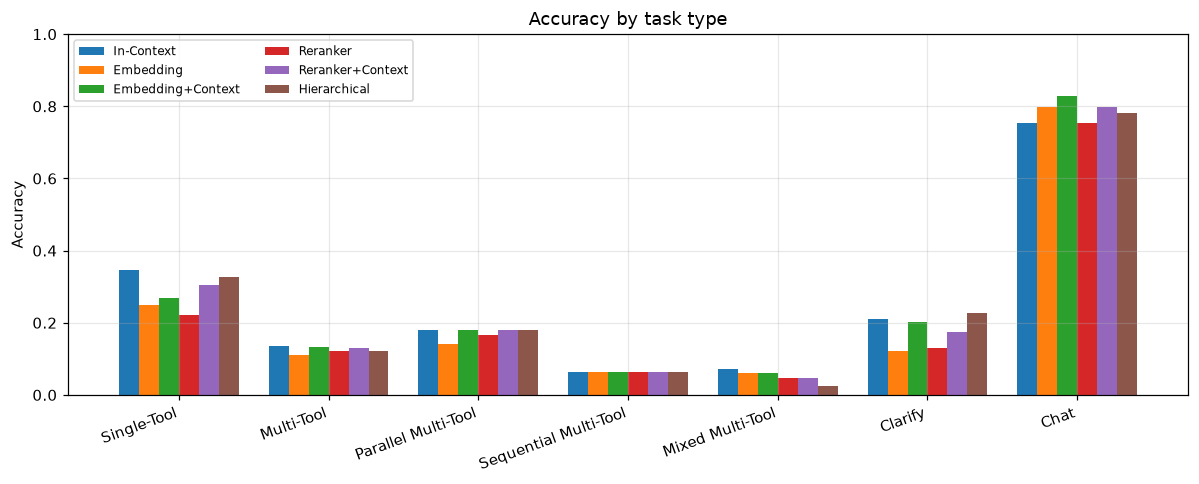

In [26]:
# Task-type accuracy
task_types = list(next(iter(strategy_data.values()))["metric"]["task_type_info"].keys())
series = {s: [strategy_data[s]["metric"]["task_type_info"][t]["accuracy"] for t in task_types] for s in STRATEGIES}
fig, ax = plt.subplots(figsize=(11, 4.5))
grouped_bar(ax, task_types, series, "Accuracy", "Accuracy by task type")
plt.tight_layout()
plt.show()


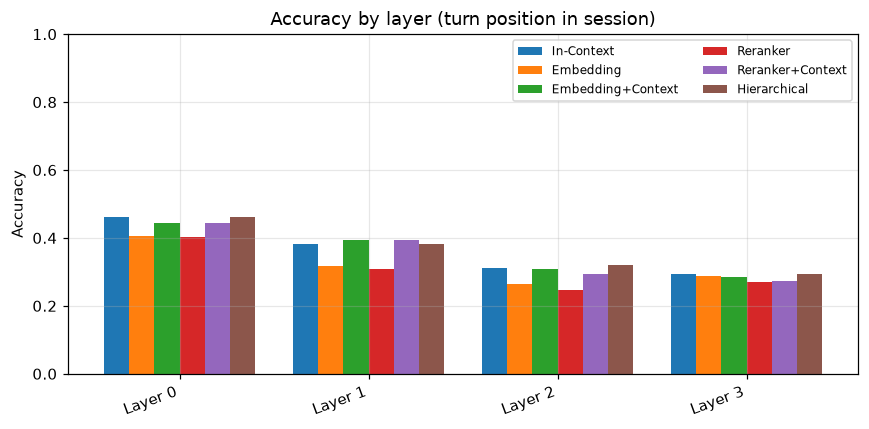

In [27]:
# Layer (turn position) accuracy
layers = list(next(iter(strategy_data.values()))["metric"]["layer_info"].keys())
series = {s: [strategy_data[s]["metric"]["layer_info"][l]["accuracy"] for l in layers] for s in STRATEGIES}
fig, ax = plt.subplots(figsize=(8, 4))
grouped_bar(ax, [f"Layer {l}" for l in layers], series, "Accuracy", "Accuracy by layer (turn position in session)")
plt.tight_layout()
plt.show()


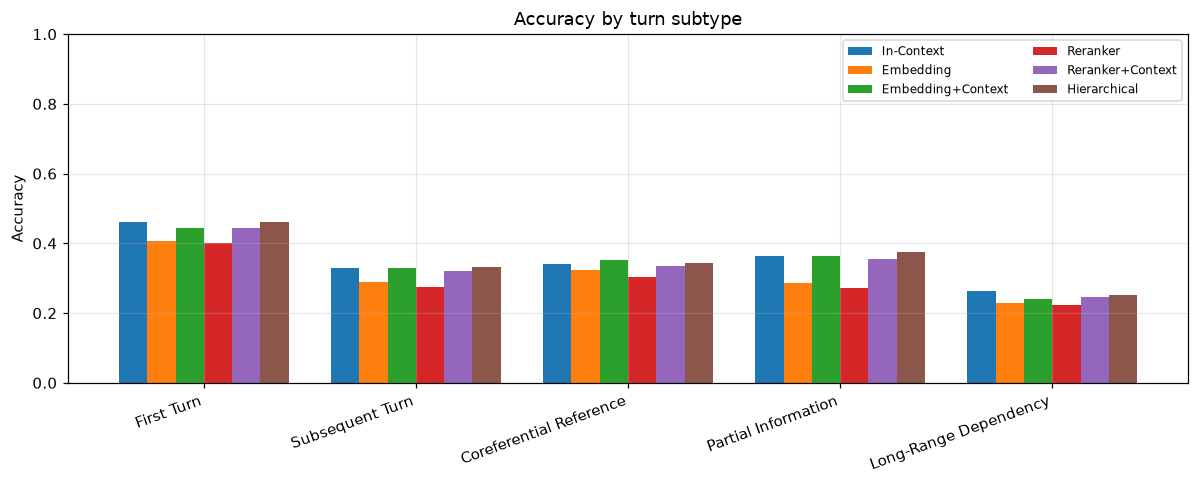

In [28]:
# Turn-subtype accuracy
subtypes = list(next(iter(strategy_data.values()))["metric"]["turn_subtype_info"].keys())
series = {s: [strategy_data[s]["metric"]["turn_subtype_info"][t]["accuracy"] for t in subtypes] for s in STRATEGIES}
fig, ax = plt.subplots(figsize=(11, 4.5))
grouped_bar(ax, subtypes, series, "Accuracy", "Accuracy by turn subtype")
plt.tight_layout()
plt.show()


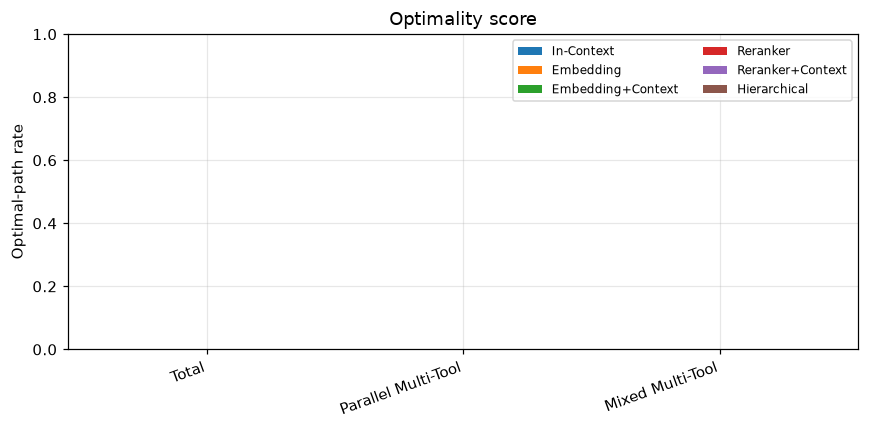

In [29]:
# Optimality score (only defined for Parallel/Mixed Multi-Tool, where multiple valid orderings exist)
optimal_keys = list(next(iter(strategy_data.values()))["metric"]["optimal_info"].keys())
series = {s: [strategy_data[s]["metric"]["optimal_info"][k]["accuracy"] for k in optimal_keys] for s in STRATEGIES}
fig, ax = plt.subplots(figsize=(8, 4))
grouped_bar(ax, optimal_keys, series, "Optimal-path rate", "Optimality score")
plt.tight_layout()
plt.show()


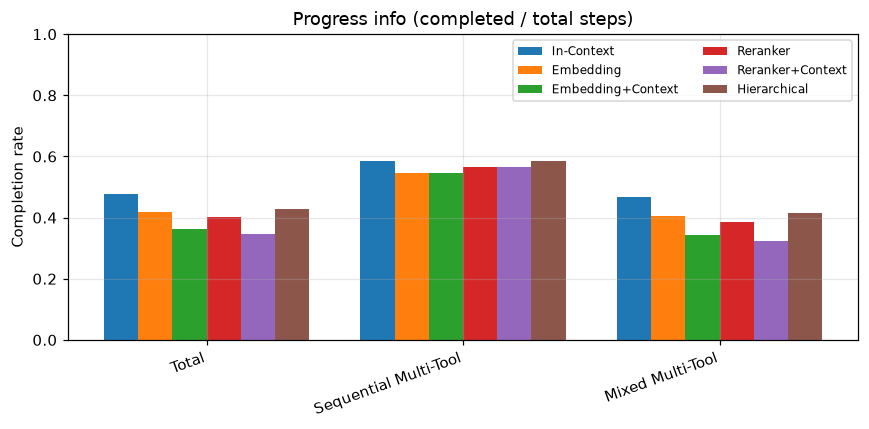

In [31]:
# Progress info: share of completed steps in multi-step tasks (Sequential/Mixed Multi-Tool)
progress_keys = list(next(iter(strategy_data.values()))["metric"]["progress_info"].keys())
series = {s: [strategy_data[s]["metric"]["progress_info"][k]["rate"] for k in progress_keys] for s in STRATEGIES}
fig, ax = plt.subplots(figsize=(8, 4))
grouped_bar(ax, progress_keys, series, "Completion rate", "Progress info (completed / total steps)")
plt.tight_layout()
plt.show()


## 3. Token count & latency comparison

`total_tokens` / `llm_latency_s` are the executing LLM's own usage. `pipeline_tokens` additionally
includes the embedding/reranker/selector overhead spent on tool selection (0 for `in_context`, which
puts all tools directly in context).


In [32]:
token_summary = task_df.groupby("strategy").agg(
    total_llm_tokens=("total_tokens", "sum"),
    total_pipeline_tokens=("pipeline_tokens", "sum"),
    avg_llm_tokens=("total_tokens", "mean"),
    avg_pipeline_tokens=("pipeline_tokens", "mean"),
    total_latency_s=("llm_latency_s", "sum"),
    avg_latency_s=("llm_latency_s", "mean"),
).reindex(STRATEGIES)
token_summary.index = [STRATEGY_LABELS[s] for s in token_summary.index]
token_summary


,total_llm_tokens,total_pipeline_tokens,avg_llm_tokens,avg_pipeline_tokens,total_latency_s,avg_latency_s
In-Context,122702102,122702102,119826.271484,119826.271484,28333.943,27.669866
Embedding,3109992,3393091,3037.101562,3313.565430,30766.191,30.045108
Embedding+Context,3129975,4194331,3056.616211,4096.026367,30845.640,30.122695
Reranker,3154458,3550034,3080.525391,3466.830078,29460.813,28.770325
Reranker+Context,3168218,4252511,3093.962891,4152.842773,31758.186,31.013854
Hierarchical,3386358,44625635,3306.990234,43579.721680,36954.388,36.088270


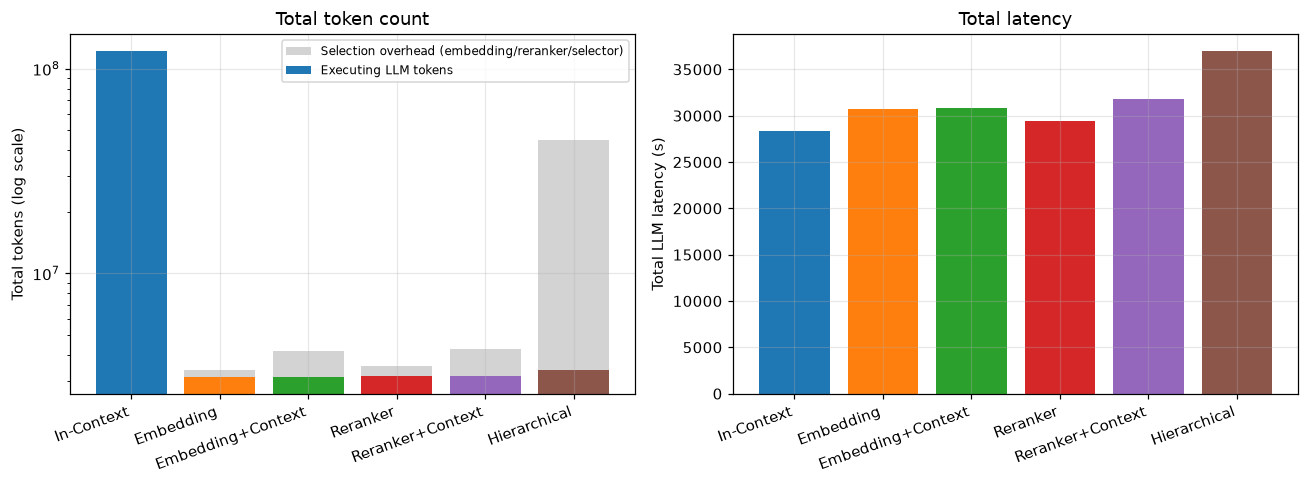

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = range(len(STRATEGIES))
labels = [STRATEGY_LABELS[s] for s in STRATEGIES]
llm_totals = [token_summary.loc[l, "total_llm_tokens"] for l in labels]
pipeline_totals = [token_summary.loc[l, "total_pipeline_tokens"] for l in labels]
axes[0].bar(x, pipeline_totals, color="lightgray", label="Selection overhead (embedding/reranker/selector)")
axes[0].bar(x, llm_totals, color=[COLORS[s] for s in STRATEGIES], label="Executing LLM tokens")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylabel("Total tokens (log scale)")
axes[0].set_yscale("log")
axes[0].set_title("Total token count")
axes[0].legend(fontsize=8)

lat_totals = [token_summary.loc[l, "total_latency_s"] for l in labels]
axes[1].bar(x, lat_totals, color=[COLORS[s] for s in STRATEGIES])
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylabel("Total LLM latency (s)")
axes[1].set_title("Total latency")

plt.tight_layout()
plt.show()


## 4. Token count vs. accuracy

Average tokens spent per task against the task accuracy achieved, per strategy.


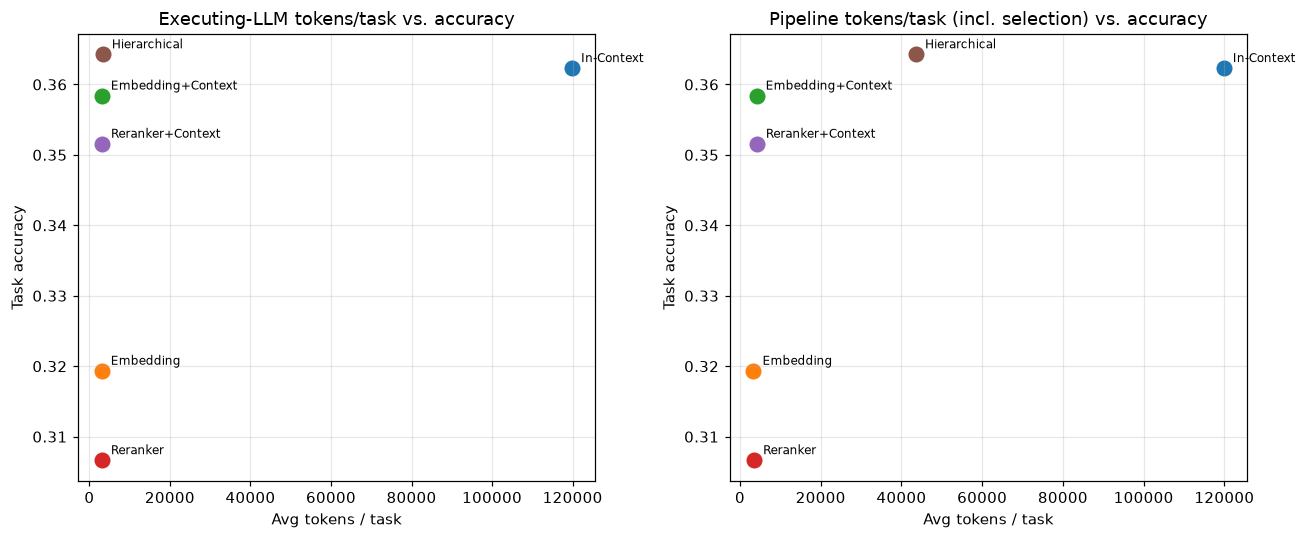

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, token_col, title in [
    (axes[0], "avg_llm_tokens", "Executing-LLM tokens/task vs. accuracy"),
    (axes[1], "avg_pipeline_tokens", "Pipeline tokens/task (incl. selection) vs. accuracy"),
]:
    for s in STRATEGIES:
        acc = strategy_data[s]["metric"]["total_info"]["task"]["accuracy"]
        tok = token_summary.loc[STRATEGY_LABELS[s], token_col]
        ax.scatter(tok, acc, s=90, color=COLORS[s], label=STRATEGY_LABELS[s])
        ax.annotate(STRATEGY_LABELS[s], (tok, acc), textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel("Avg tokens / task")
    ax.set_ylabel("Task accuracy")
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 5. Inter-strategy comparison: unique wins

For each strategy, the number of tasks that *only that strategy* solved correctly (all other five
strategies got it wrong).


In-Context           unique wins:  16   total correct: 371
Embedding            unique wins:   5   total correct: 327
Embedding+Context    unique wins:  11   total correct: 367
Reranker             unique wins:   3   total correct: 314
Reranker+Context     unique wins:   5   total correct: 360
Hierarchical         unique wins:  12   total correct: 373


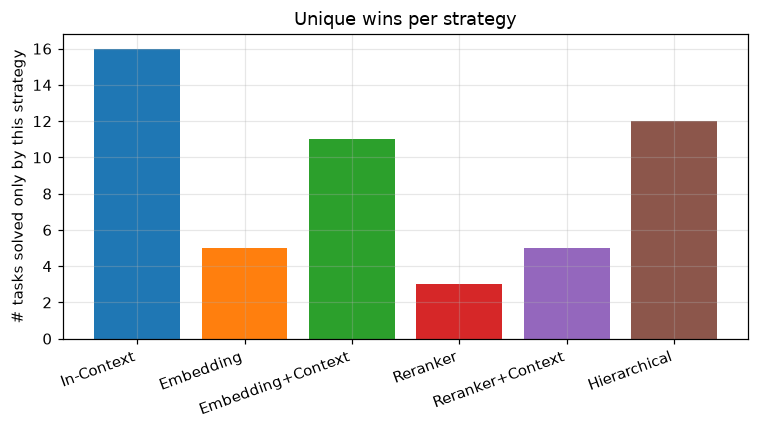

In [36]:
correct_sets = {
    s: {key for key, t in strategy_data[s]["tasks"].items() if t["correct"]}
    for s in STRATEGIES
}
all_keys = set(gold_index.keys())

solved_by_count = Counter()
for key in all_keys:
    for s in STRATEGIES:
        if key in correct_sets[s]:
            solved_by_count[key] += 1

unique_wins = {}
for s in STRATEGIES:
    unique_wins[s] = sorted(
        key for key in correct_sets[s]
        if solved_by_count[key] == 1
    )

for s in STRATEGIES:
    print(f"{STRATEGY_LABELS[s]:20s} unique wins: {len(unique_wins[s]):3d}   total correct: {len(correct_sets[s]):3d}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(STRATEGIES)), [len(unique_wins[s]) for s in STRATEGIES], color=[COLORS[s] for s in STRATEGIES])
ax.set_xticks(range(len(STRATEGIES)))
ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], rotation=20, ha="right")
ax.set_ylabel("# tasks solved only by this strategy")
ax.set_title("Unique wins per strategy")
plt.tight_layout()
plt.show()


## 6. Gold-tool coverage of the tool selection stage

For each task, the share of gold (ground-truth) tool names that appear anywhere in the set of tools
the selection stage handed to the LLM. `in_context` is excluded since it passes every tool through
without a selection step.


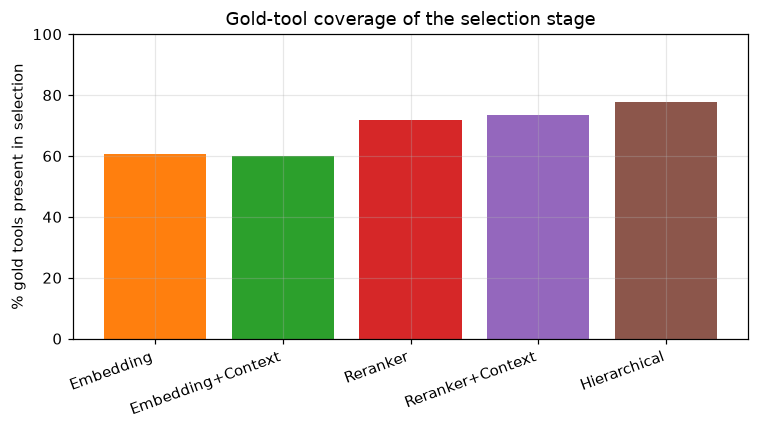

,mean_gold_tool_coverage
strategy,
embedding,0.605946
embedding_context,0.598720
reranker,0.718077
reranker_context,0.735373
hierarchical,0.777886


In [37]:
selection_strategies = [s for s in STRATEGIES if s != "in_context"]
coverage_rows = []
for s in selection_strategies:
    selection = strategy_data[s]["selection"]
    for key, gold in gold_index.items():
        gold_tools = set(gold["gold_tools_unique"])
        if not gold_tools:
            continue  # Chat/no-tool tasks have nothing to cover
        selected = selection.get(key, set())
        coverage_rows.append({
            "strategy": s,
            "task_id": key[0],
            "task_idx": key[1],
            "coverage": len(gold_tools & selected) / len(gold_tools),
        })
coverage_df = pd.DataFrame(coverage_rows)
coverage_summary = coverage_df.groupby("strategy")["coverage"].mean().reindex(selection_strategies)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(selection_strategies)), coverage_summary.values * 100,
       color=[COLORS[s] for s in selection_strategies])
ax.set_xticks(range(len(selection_strategies)))
ax.set_xticklabels([STRATEGY_LABELS[s] for s in selection_strategies], rotation=20, ha="right")
ax.set_ylabel("% gold tools present in selection")
ax.set_title("Gold-tool coverage of the selection stage")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

coverage_summary.rename("mean_gold_tool_coverage").to_frame()


## 7. Single-task deep dive

Compare, for one task, the gold trajectory against what each strategy actually selected, called and
answered. Change `TASK_ID` / `TASK_IDX` below to inspect a different task; use the `unique_wins` /
`coverage_df` tables above to find interesting candidates (e.g. `sorted(unique_wins["hierarchical"])`).


In [45]:
def show_task_comparison(task_id: str, task_idx: int, strategies: list[str] = STRATEGIES):
    key = (task_id, task_idx)
    gold = gold_index.get(key)
    if gold is None:
        print(f"No such task: {key}")
        return

    print(f"### {task_id}[{task_idx}]  ·  {gold['task_type']}  ·  {gold['turn_type']}"
          + (f" / {gold['turn_subtype']}" if gold["turn_subtype"] else ""))
    print(f"Query: {gold['query']}\n")

    print("--- Gold trajectory ---")
    for a in gold["gold_actions"]:
        name = a.get("action", {}).get("name")
        args = a.get("action", {}).get("arguments")
        if name == "prepare_to_answer":
            print(f"  => final answer: {a.get('observation')}")
        else:
            print(f"  call {name}({args})")
    print()

    for s in strategies:
        task = strategy_data[s]["tasks"].get(key, {})
        selected = sorted(strategy_data[s]["selection"].get(key, set()))
        executed = strategy_data[s]["tool_calls"].get(key, [])
        print(f"--- {STRATEGY_LABELS[s]} ({'CORRECT' if task.get('correct') else 'INCORRECT'}"
              f"{', optimal' if task.get('optimal') else ''}) ---")
        if selected:
            print(f"  selected tools : {selected}")
        for call in executed:
            print(f"  called         : {call['name']}({call['arguments']})")
        if task.get("final_answer"):
            print(f"  final answer   : {task['final_answer']}")
        print()


# Example: first task of the first benchmark session
show_task_comparison("wild_tool_bench_7", 0)


### wild_tool_bench_7[0]  ·  Single-Tool  ·  First Turn
Query: Could you please provide some detailed information about Ontario, Canada? Such as its population, area, economic situation, etc.

--- Gold trajectory ---
  call getDivisionDetails({'countryCode': 'CA', 'divisionCode': 'ON'})
  => final answer: Here is detailed information about Ontario, Canada:

- **Name**: Ontario
- **Country Code**: CA
- **Administrative Division Code**: ON
- **Type**: Province
- **Population**: 14,734,014
- **Area**: 1,076,395 square kilometers
- **GDP**: $857 billion
- **Capital**: Toronto
- **Largest City**: Toronto
- **Official Language**: English
- **Description**: Ontario is the most populous province in Canada and the second-largest in area. Its capital and largest city is Toronto. Ontario has a highly developed economy, with its GDP ranking among the top in Canadian provinces.

I hope this information is helpful to you! If you have any other questions, please feel free to let me know.

--- In-Cont